Episode 1000 | Genre Accuracy: 0.3390 | Song Satisfaction: 0.3760 | Avg Song Rating: 2.36
Macro F1: 0.1977 | Micro F1: 0.3390 | Macro Precision: 0.2032 | Macro Recall: 0.2390
Episode 2000 | Genre Accuracy: 0.5750 | Song Satisfaction: 0.5190 | Avg Song Rating: 2.53
Macro F1: 0.4651 | Micro F1: 0.5750 | Macro Precision: 0.4688 | Macro Recall: 0.4929
Episode 3000 | Genre Accuracy: 0.6670 | Song Satisfaction: 0.6190 | Avg Song Rating: 2.64
Macro F1: 0.6124 | Micro F1: 0.6670 | Macro Precision: 0.6068 | Macro Recall: 0.6543
Episode 4000 | Genre Accuracy: 0.7390 | Song Satisfaction: 0.6560 | Avg Song Rating: 2.64
Macro F1: 0.7106 | Micro F1: 0.7390 | Macro Precision: 0.7144 | Macro Recall: 0.7351
Episode 5000 | Genre Accuracy: 0.8130 | Song Satisfaction: 0.7170 | Avg Song Rating: 2.78
Macro F1: 0.8068 | Micro F1: 0.8130 | Macro Precision: 0.8089 | Macro Recall: 0.8070
Episode 6000 | Genre Accuracy: 0.8600 | Song Satisfaction: 0.7190 | Avg Song Rating: 2.70
Macro F1: 0.8519 | Micro F1: 0.8600

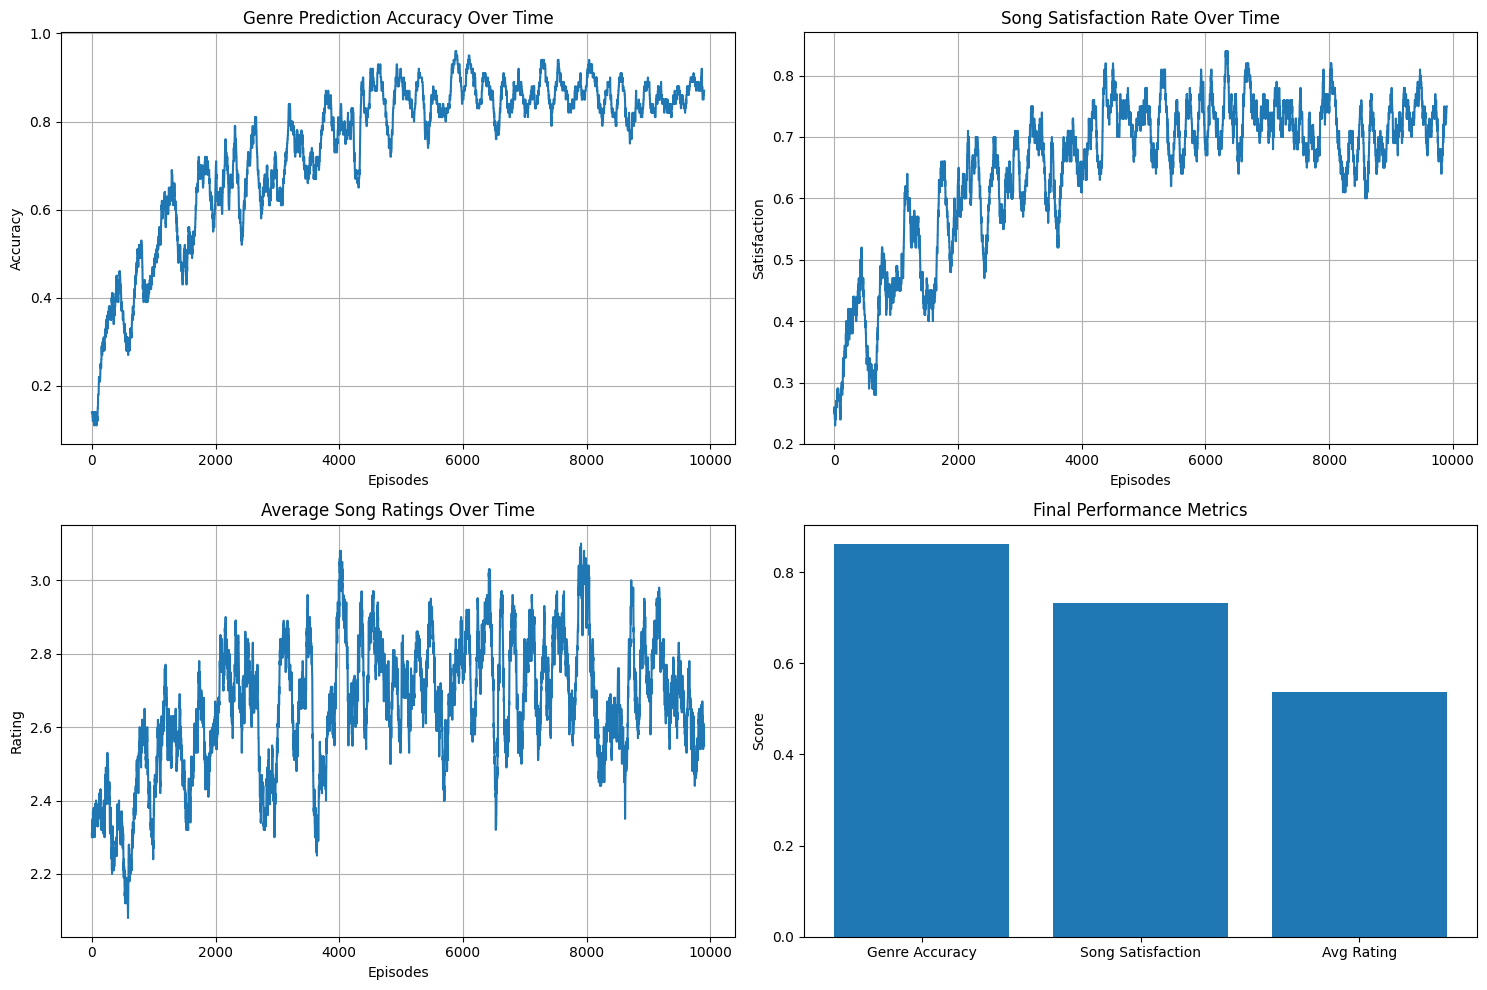

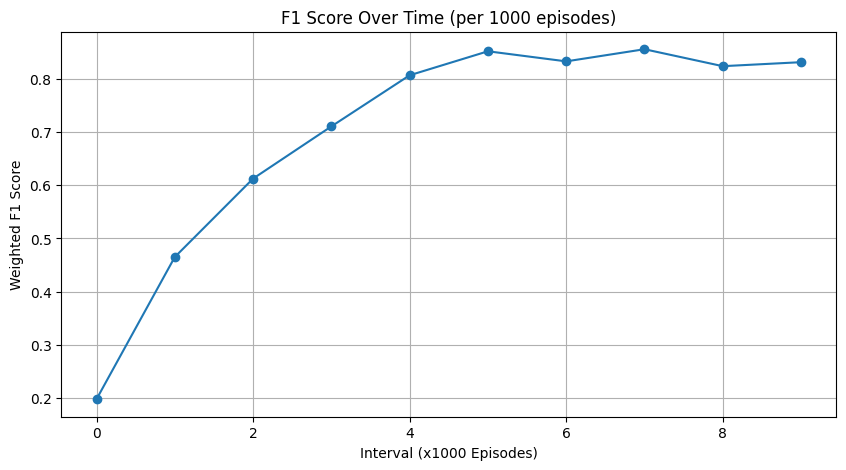


GENRE MAPPING
0: dance pop
1: album rock
2: pop
3: australian rock
4: adult standards
5: australian pop
6: alternative metal
7: australian dance
8: boy band
9: australian alternative rock

PRODUCTION RECOMMENDATION EXAMPLE
Predicted Genre: australian dance
Confidence: 0.133
Recommended Song: Never Be Like You by Flume, kai
Alternative Genres: australian dance, adult standards, pop


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score

# ============================================================================
# DATA PREPROCESSING SECTION
# ============================================================================

music_df = pd.read_csv("top_10000_1960-now.csv")
music_df = music_df[music_df['Artist Genres'].notnull() & music_df['Track Name'].notnull() &
                    music_df['Artist Name(s)'].notnull() & music_df['Album Name'].notnull() & music_df['Popularity'].notnull()]
music_df['label_column'] = music_df['Artist Genres'].str.split(',').str[0].str.strip()
top_genres = music_df['label_column'].value_counts().nlargest(10).index.tolist()
music_df = music_df[music_df['label_column'].isin(top_genres)]

genre_to_idx = {genre: idx for idx, genre in enumerate(top_genres)}
idx_to_genre = {idx: genre for genre, idx in genre_to_idx.items()}

# ============================================================================
# SONG RECOMMENDATION SYSTEM
# ============================================================================

class SongRecommender:
    def __init__(self, music_df, genre_to_idx):
        self.music_df = music_df
        self.genre_to_idx = genre_to_idx
        self.user_song_history = {}
        self.genre_songs = {genre: music_df[music_df['label_column'] == genre] for genre in genre_to_idx.keys()}

    def get_song_recommendation(self, user_id, genre_idx, strategy='popularity_weighted'):
        genre = idx_to_genre[genre_idx]
        genre_songs = self.genre_songs[genre]

        if genre_songs.empty:
            return None

        if user_id not in self.user_song_history:
            self.user_song_history[user_id] = set()

        available_songs = genre_songs[~genre_songs.index.isin(self.user_song_history[user_id])]
        if available_songs.empty:
            self.user_song_history[user_id] = set()
            available_songs = genre_songs

        if strategy == 'random':
            selected_song = available_songs.sample(n=1).iloc[0]
        elif strategy == 'popularity_weighted':
            if 'Popularity' in available_songs.columns:
                weights = available_songs['Popularity'].values
                if np.sum(weights) > 0 and not np.isnan(weights).all():
                    weights = weights / weights.sum()
                    selected_idx = np.random.choice(available_songs.index, p=weights)
                    selected_song = available_songs.loc[selected_idx]
                else:
                    selected_song = available_songs.sample(n=1).iloc[0]
            else:
                selected_song = available_songs.sample(n=1).iloc[0]
        elif strategy == 'diverse':
            user_artists = {song_info.get('artist', '') for song_info in [self.music_df.loc[idx].to_dict() for idx in self.user_song_history[user_id]]}
            diverse_songs = available_songs[~available_songs['Artist Name(s)'].isin(user_artists)]
            selected_song = diverse_songs.sample(n=1).iloc[0] if not diverse_songs.empty else available_songs.sample(n=1).iloc[0]
        else:
            selected_song = available_songs.sample(n=1).iloc[0]

        self.user_song_history[user_id].add(selected_song.name)

        return {
            'track_name': selected_song['Track Name'],
            'artist': selected_song['Artist Name(s)'],
            'album': selected_song['Album Name'],
            'genre': genre,
            'popularity': selected_song.get('Popularity', 'N/A'),
            'year': selected_song.get('Release Date', 'N/A')
        }

song_recommender = SongRecommender(music_df, genre_to_idx)

# ============================================================================
# SIMULATED USER CLASS (ENHANCED)
# ============================================================================

class SimulatedUser:
    def __init__(self, id, initial_pref):
        self.id = id
        self.preference = initial_pref
        self.preference_change_prob = 0.05
        self.liked_songs = []
        self.disliked_songs = []

    def respond(self, action_idx, song_info=None):
        if random.random() < self.preference_change_prob:
            self.preference = random.choice(list(genre_to_idx.values()))

        genre_reward = 1 if action_idx == self.preference else 0
        song_feedback = None

        if song_info:
            likes_song = random.random() < 0.8 if genre_reward == 1 else random.random() < 0.2
            song_feedback = {
                'likes_song': likes_song,
                'song_rating': random.randint(1, 5) if likes_song else random.randint(1, 3),
                'track_name': song_info['track_name'],
                'artist': song_info['artist']
            }

            (self.liked_songs if likes_song else self.disliked_songs).append(song_info)

        return genre_reward, song_feedback

# ============================================================================
# ENVIRONMENT SETUP
# ============================================================================

# Create a population of 50 simulated users with random initial preferences
# This simulates a diverse user base for the recommendation system
users = [SimulatedUser(i, random.choice(list(genre_to_idx.values()))) for i in range(50)]

# ============================================================================
# DEEP Q-NETWORK MODEL DEFINITION
# ============================================================================

class DQN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(DQN, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim)
        )

    def forward(self, x):
        return self.layers(x)

# ============================================================================
# HYPERPARAMETERS AND MODEL INITIALIZATION
# ============================================================================

INPUT_DIM, OUTPUT_DIM = 10, 10
GAMMA, EPSILON = 0.95, 0.1
LR, BATCH_SIZE, MEMORY_SIZE, EPISODES = 0.001, 32, 1000, 10000

model = DQN(INPUT_DIM, OUTPUT_DIM)
optimizer = optim.Adam(model.parameters(), lr=LR)
memory = deque(maxlen=MEMORY_SIZE)

reward_history, song_feedback_history = [], []

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def get_user_state(user):
    state = [0] * INPUT_DIM
    state[user.preference] = 1
    return state

def select_action(state, epsilon):
    if random.random() < epsilon:
        return random.randint(0, OUTPUT_DIM - 1)
    else:
        with torch.no_grad():
            state_tensor = torch.FloatTensor(state)
            return torch.argmax(model(state_tensor)).item()

def recommend_complete_package(user, epsilon, strategy='popularity_weighted'):
    state = get_user_state(user)
    action = select_action(state, epsilon)
    song_info = song_recommender.get_song_recommendation(user.id, action, strategy)
    genre_reward, song_feedback = user.respond(action, song_info)
    return action, song_info, genre_reward, song_feedback

# ============================================================================
# MAIN TRAINING LOOP (ENHANCED)
# ============================================================================

true_labels = []
predicted_labels = []
f1_scores = []

for episode in range(EPISODES):
    user = random.choice(users)
    state = get_user_state(user)
    action, song_info, genre_reward, song_feedback = recommend_complete_package(user, EPSILON)

    true_labels.append(user.preference)
    predicted_labels.append(action)

    next_state = get_user_state(user)
    memory.append((state, action, genre_reward, next_state))

    if len(memory) >= BATCH_SIZE:
        batch = random.sample(memory, BATCH_SIZE)
        states, actions, rewards, next_states = zip(*batch)

        states = torch.FloatTensor(states)
        actions = torch.LongTensor(actions).unsqueeze(1)
        rewards = torch.FloatTensor(rewards)
        next_states = torch.FloatTensor(next_states)

        q_values = model(states).gather(1, actions).squeeze()
        next_q_values = model(next_states).max(1)[0].detach()
        targets = rewards + GAMMA * next_q_values

        loss = nn.MSELoss()(q_values, targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    reward_history.append(genre_reward)
    if song_feedback:
        song_feedback_history.append(song_feedback)

    if (episode + 1) % 1000 == 0:
        avg_genre_reward = np.mean(reward_history[-1000:])
        recent_fb = song_feedback_history[-1000:] if len(song_feedback_history) >= 1000 else song_feedback_history
        song_satisfaction = np.mean([fb['likes_song'] for fb in recent_fb]) if recent_fb else 0
        avg_song_rating = np.mean([fb['song_rating'] for fb in recent_fb]) if recent_fb else 0

        f1_macro = f1_score(true_labels, predicted_labels, average='macro')
        f1_micro = f1_score(true_labels, predicted_labels, average='micro')
        precision_macro = precision_score(true_labels, predicted_labels, average='macro')
        recall_macro = recall_score(true_labels, predicted_labels, average='macro')

        f1_scores.append(f1_macro)  # Keeping macro F1 for the existing plot

        print(f"Episode {episode + 1} | Genre Accuracy: {avg_genre_reward:.4f} | "
              f"Song Satisfaction: {song_satisfaction:.4f} | Avg Song Rating: {avg_song_rating:.2f}")
        print(f"Macro F1: {f1_macro:.4f} | Micro F1: {f1_micro:.4f} | "
              f"Macro Precision: {precision_macro:.4f} | Macro Recall: {recall_macro:.4f}")

        true_labels.clear()
        predicted_labels.clear()

# ============================================================================
# DEMONSTRATION AND TESTING
# ============================================================================

def demonstrate_recommendations(num_demos=5):
    print("\n" + "="*80)
    print("RECOMMENDATION SYSTEM DEMONSTRATION")
    print("="*80)

    demo_epsilon = 0.0

    for i in range(num_demos):
        demo_user = random.choice(users)
        preferred_genre = idx_to_genre[demo_user.preference]

        print(f"\nDemo {i+1}:")
        print(f"User ID: {demo_user.id}")
        print(f"User's True Preference: {preferred_genre}")
        print("-" * 40)

        action, song_info, genre_reward, song_feedback = recommend_complete_package(
            demo_user, demo_epsilon, strategy='popularity_weighted'
        )

        predicted_genre = idx_to_genre[action]
        print(f"Predicted Genre: {predicted_genre}")
        print(f"Genre Match: {'yes' if genre_reward == 1 else 'no'}")

        if song_info:
            print(f"\nRecommended Song:")
            print(f"  Title: {song_info['track_name']}")
            print(f"  Artist: {song_info['artist']}")
            print(f"  Album: {song_info['album']}")
            print(f"  Popularity: {song_info['popularity']}")

            if song_feedback:
                print(f"\nUser Feedback:")
                print(f"  Likes Song: {'yes' if song_feedback['likes_song'] else 'no'}")
                print(f"  Rating: {song_feedback['song_rating']}/5")

demonstrate_recommendations()

# ============================================================================
# RESULTS VISUALIZATION
# ============================================================================

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

smoothed_rewards = np.convolve(reward_history, np.ones(100)/100, mode='valid')
ax1.plot(smoothed_rewards)
ax1.set_title("Genre Prediction Accuracy Over Time")
ax1.set_xlabel("Episodes")
ax1.set_ylabel("Accuracy")
ax1.grid(True)

if song_feedback_history:
    song_likes = [1 if fb['likes_song'] else 0 for fb in song_feedback_history]
    smoothed_song_satisfaction = np.convolve(song_likes, np.ones(100)/100, mode='valid')
    ax2.plot(smoothed_song_satisfaction)
    ax2.set_title("Song Satisfaction Rate Over Time")
    ax2.set_xlabel("Episodes")
    ax2.set_ylabel("Satisfaction")
    ax2.grid(True)

    song_ratings = [fb['song_rating'] for fb in song_feedback_history]
    smoothed_ratings = np.convolve(song_ratings, np.ones(100)/100, mode='valid')
    ax3.plot(smoothed_ratings)
    ax3.set_title("Average Song Ratings Over Time")
    ax3.set_xlabel("Episodes")
    ax3.set_ylabel("Rating")
    ax3.grid(True)

ax4.bar(['Genre Accuracy', 'Song Satisfaction', 'Avg Rating'],
        [np.mean(reward_history[-1000:]),
         np.mean([fb['likes_song'] for fb in song_feedback_history[-1000:]]) if song_feedback_history else 0,
         np.mean([fb['song_rating'] for fb in song_feedback_history[-1000:]])/5 if song_feedback_history else 0])
ax4.set_title("Final Performance Metrics")
ax4.set_ylabel("Score")

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(f1_scores, marker='o')
plt.title("F1 Score Over Time (per 1000 episodes)")
plt.xlabel("Interval (x1000 Episodes)")
plt.ylabel("Weighted F1 Score")
plt.grid(True)
plt.show()

print("\n" + "="*50)
print("GENRE MAPPING")
print("="*50)
for idx, genre in idx_to_genre.items():
    print(f"{idx}: {genre}")

# ============================================================================
# FINAL RECOMMENDATION FUNCTION FOR PRODUCTION USE
# ============================================================================

def get_recommendation_for_user(user_id, user_preference_history=None, strategy='popularity_weighted'):
    if user_preference_history:
        recent_preference = max(set(user_preference_history), key=user_preference_history.count)
        state = [0] * INPUT_DIM
        state[recent_preference] = 1
    else:
        state = [1/INPUT_DIM] * INPUT_DIM

    with torch.no_grad():
        state_tensor = torch.FloatTensor(state)
        q_values = model(state_tensor)
        predicted_genre_idx = torch.argmax(q_values).item()

    song_info = song_recommender.get_song_recommendation(user_id, predicted_genre_idx, strategy)

    return {
        'predicted_genre': idx_to_genre[predicted_genre_idx],
        'genre_confidence': torch.softmax(q_values, dim=0)[predicted_genre_idx].item(),
        'song_recommendation': song_info,
        'alternative_genres': [idx_to_genre[i] for i in torch.topk(q_values, 3)[1].tolist()]
    }

print("\n" + "="*60)
print("PRODUCTION RECOMMENDATION EXAMPLE")
print("="*60)
example_recommendation = get_recommendation_for_user('user_123', strategy='diverse')
print(f"Predicted Genre: {example_recommendation['predicted_genre']}")
print(f"Confidence: {example_recommendation['genre_confidence']:.3f}")
if example_recommendation['song_recommendation']:
    song = example_recommendation['song_recommendation']
    print(f"Recommended Song: {song['track_name']} by {song['artist']}")
print(f"Alternative Genres: {', '.join(example_recommendation['alternative_genres'])}")